# Pandas Day 4: Data Visualization with Matplotlib & Seaborn

## Week 3, Day 4 - Telling Stories with Data

---

### Today's Journey (2.5 Hours)

| Part | Topic | Duration |
|------|-------|---------|
| 1 | Why Visualization Matters | ~15 min |
| 2 | Matplotlib Fundamentals | ~35 min |
| | **BREAK 1** | 10 min |
| 3 | Seaborn: Statistical Visualization | ~35 min |
| 4 | Scatter Plots & Relationships | ~20 min |
| | **BREAK 2** | 10 min |
| 5 | Box Plots & Distributions | ~20 min |
| 6 | Advanced: Pair Plots & Heatmaps | ~20 min |
| 7 | Mini-Project: Complete Dashboard | ~25 min |

---

```
TODAY'S PROMISE:

    +---------------------------------------------------------------------+
    |                                                                     |
    |   BEFORE (Yesterday):                                              |
    |                                                                     |
    |   df['sales'].mean()                                               |
    |   -> 47832.5                                                       |
    |                                                                     |
    |   "Here's a number. Trust me, it's important."                     |
    |                                                                     |
    |                                                                     |
    |   AFTER (Today):                                                   |
    |                                                                     |
    |   [A beautiful chart showing trends over time,                     |
    |    with clear peaks in Q4, a dip in February,                      |
    |    and annotations highlighting key events]                        |
    |                                                                     |
    |   "Sales spike 40% every December - here's the pattern."          |
    |                                                                     |
    +---------------------------------------------------------------------+

    A picture is worth a thousand rows of data.
```

## Setup - Run This First!

**IMPORTANT: Run this cell before anything else.**

In [1]:
# ============================================
# RUN THIS CELL FIRST - All imports for today
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 20)

# Set default figure size
plt.rcParams['figure.figsize'] = (10, 6)

print("All libraries loaded! Ready for visualization.")

All libraries loaded! Ready for visualization.


## Where Visualization Fits in Your Workflow

```
THE COMPLETE DATA ANALYSIS PIPELINE:

    +---------+    +---------+    +-------------+    +-------------+    +---------+
    |  Day 1  | -> |  Day 2  | -> |    Day 3    | -> |   Day 4     | -> |  Day 5  |
    |  LOAD   |    | FILTER  |    | PREPROCESS  |    |  VISUALIZE  |    |  MODEL  |
    | EXPLORE |    | SELECT  |    |   CLEAN     |    |   PRESENT   |    | PREDICT |
    +---------+    +---------+    +-------------+    +-------------+    +---------+
         |              |               |                  |
         |              |               |                  |
    head, shape     loc, iloc      fillna, encode      plt, sns
    info, describe  filtering      scale, engineer     charts!


    VISUALIZATION SERVES TWO PURPOSES:

    1. EXPLORATION  ->  Understand your data (for YOU)
       "What patterns exist? Any outliers? How is it distributed?"

    2. COMMUNICATION  ->  Tell the story (for OTHERS)
       "Here's what the data says. Here's why it matters."

    Today: You learn BOTH.
```

---

# Part 1: Why Data Visualization Matters

## The Human Brain is Wired for Images

---

In [2]:
# Anscombe's Quartet - The Famous Example
anscombe = sns.load_dataset('anscombe')

# Show statistics for each dataset
print("Statistics for Anscombe's Quartet:")
print("=" * 60)
for dataset in ['I', 'II', 'III', 'IV']:
    data = anscombe[anscombe['dataset'] == dataset]
    print(f"\nDataset {dataset}:")
    print(f"  X mean: {data['x'].mean():.2f}  |  Y mean: {data['y'].mean():.2f}")
    print(f"  X std:  {data['x'].std():.2f}  |  Y std:  {data['y'].std():.2f}")
    corr = data['x'].corr(data['y'])
    print(f"  Correlation: {corr:.3f}")

print("\n" + "=" * 60)
print("The statistics are nearly IDENTICAL!")

Statistics for Anscombe's Quartet:

Dataset I:
  X mean: 9.00  |  Y mean: 7.50
  X std:  3.32  |  Y std:  2.03
  Correlation: 0.816

Dataset II:
  X mean: 9.00  |  Y mean: 7.50
  X std:  3.32  |  Y std:  2.03
  Correlation: 0.816

Dataset III:
  X mean: 9.00  |  Y mean: 7.50
  X std:  3.32  |  Y std:  2.03
  Correlation: 0.816

Dataset IV:
  X mean: 9.00  |  Y mean: 7.50
  X std:  3.32  |  Y std:  2.03
  Correlation: 0.817

The statistics are nearly IDENTICAL!


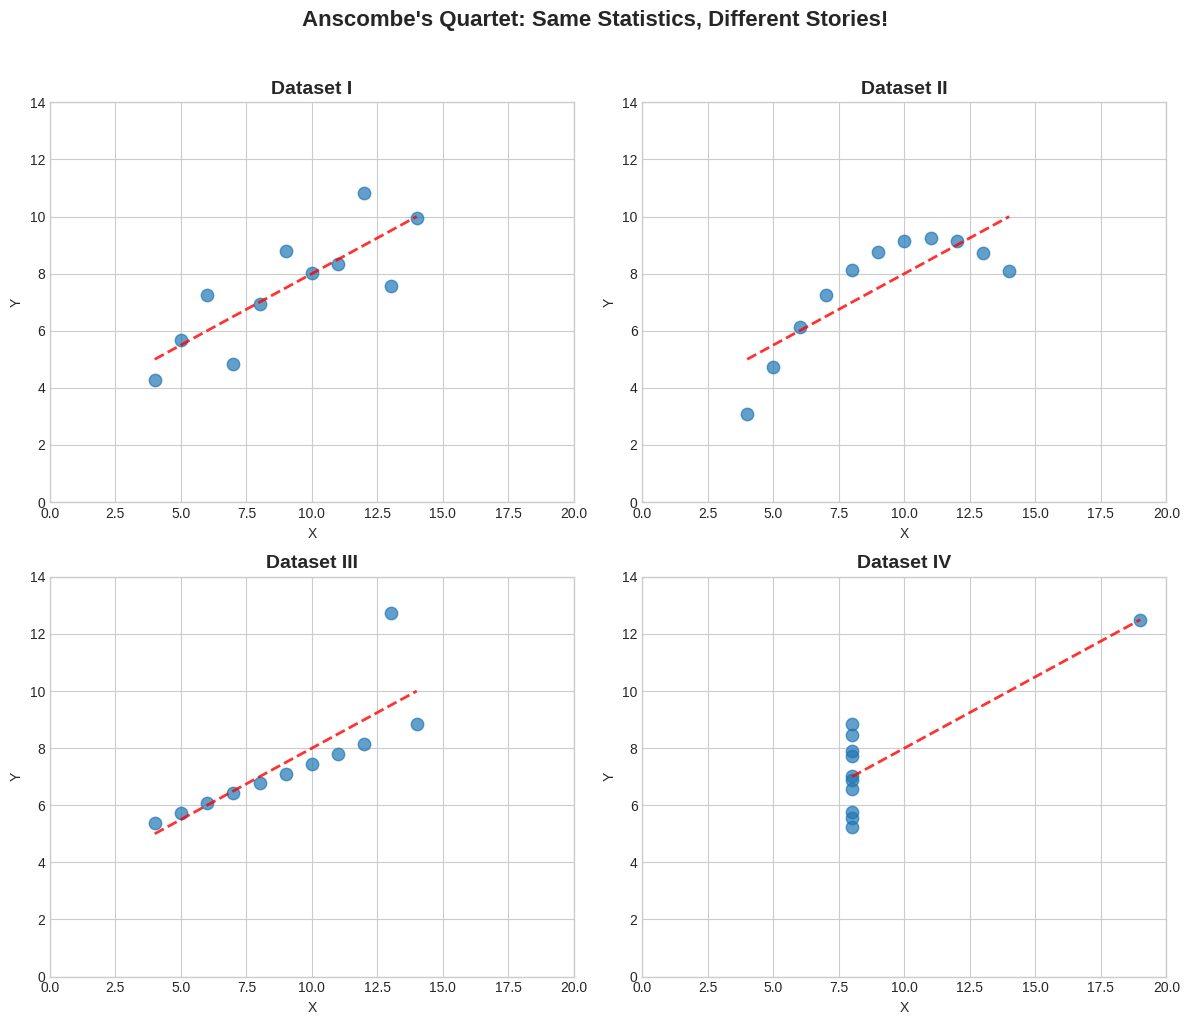

Same mean, same variance, same correlation - but WILDLY different data!


In [3]:
# Now VISUALIZE the four datasets
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

datasets = ['I', 'II', 'III', 'IV']
positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

for dataset, (row, col) in zip(datasets, positions):
    data = anscombe[anscombe['dataset'] == dataset]
    ax = axes[row, col]
    ax.scatter(data['x'], data['y'], s=80, alpha=0.7)
    ax.set_title(f'Dataset {dataset}', fontsize=14, fontweight='bold')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_xlim(0, 20)
    ax.set_ylim(0, 14)

    # Add regression line
    z = np.polyfit(data['x'], data['y'], 1)
    p = np.poly1d(z)
    ax.plot(data['x'].sort_values(), p(data['x'].sort_values()),
            'r--', alpha=0.8, linewidth=2)

plt.suptitle("Anscombe's Quartet: Same Statistics, Different Stories!",
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Same mean, same variance, same correlation - but WILDLY different data!")

## The Purpose of Different Chart Types

```
CHOOSING THE RIGHT CHART:

    +---------------------------------------------------------------------+
    |                                                                     |
    |   LINE CHART                                                        |
    |   ----------                                                        |
    |   Purpose: Show TRENDS over time                                    |
    |   Use when: Data changes over a sequence (time, order)              |
    |   Example: Temperature over a week, stock prices over a year        |
    |                                                                     |
    |   BAR CHART                                                         |
    |   ---------                                                         |
    |   Purpose: COMPARE categories                                       |
    |   Use when: Comparing distinct groups                               |
    |   Example: Sales by region, grades by subject                       |
    |                                                                     |
    |   HISTOGRAM                                                         |
    |   ---------                                                         |
    |   Purpose: Show DISTRIBUTION of one variable                        |
    |   Use when: Understanding how values are spread out                 |
    |   Example: Age distribution, test score distribution                |
    |                                                                     |
    |   SCATTER PLOT                                                      |
    |   ------------                                                      |
    |   Purpose: Show RELATIONSHIP between two variables                  |
    |   Use when: Exploring correlations or patterns                      |
    |   Example: Height vs weight, study time vs grades                   |
    |                                                                     |
    |   BOX PLOT                                                          |
    |   --------                                                          |
    |   Purpose: Compare DISTRIBUTIONS across groups                      |
    |   Use when: Comparing spread and outliers across categories         |
    |   Example: Salary by department, scores by class                    |
    |                                                                     |
    +---------------------------------------------------------------------+
```

---

# Part 2: Matplotlib Fundamentals

## The Foundation of Python Visualization

---

## Line Plots: Showing Trends Over Time

In [4]:
# Create sample data: Temperature over a week
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
temperatures = [72, 74, 76, 80, 82, 78, 75]

print("Temperature data:")
for day, temp in zip(days, temperatures):
    print(f"  {day}: {temp} F")

Temperature data:
  Mon: 72 F
  Tue: 74 F
  Wed: 76 F
  Thu: 80 F
  Fri: 82 F
  Sat: 78 F
  Sun: 75 F


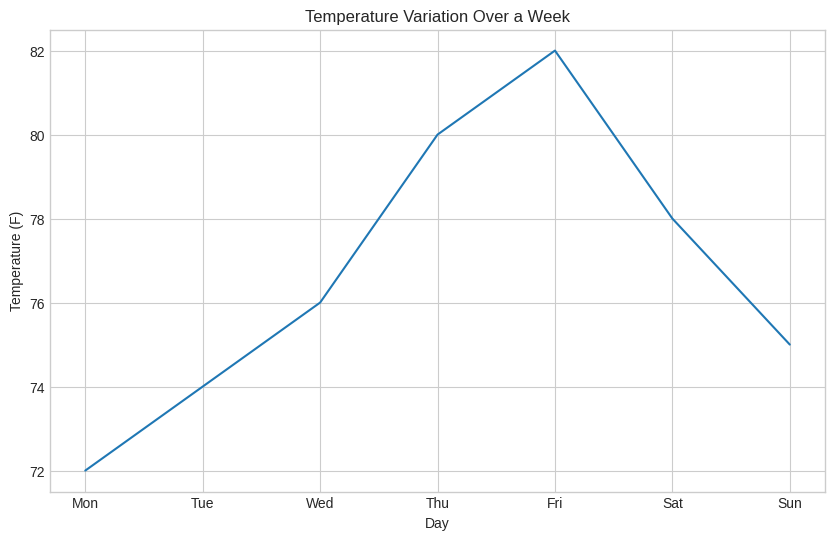

In [5]:
# ===========================================
# LIVE CODING: Basic Line Plot
# ===========================================
# Create a line plot with:
#   - plt.plot(x_data, y_data)
#   - plt.title('...')
#   - plt.xlabel('...')
#   - plt.ylabel('...')
#   - plt.show()
plt.plot(days, temperatures)
plt.title("Temperature Variation Over a Week")
plt.xlabel("Day")
plt.ylabel("Temperature (F)")
plt.show()

## Customizing Line Plots

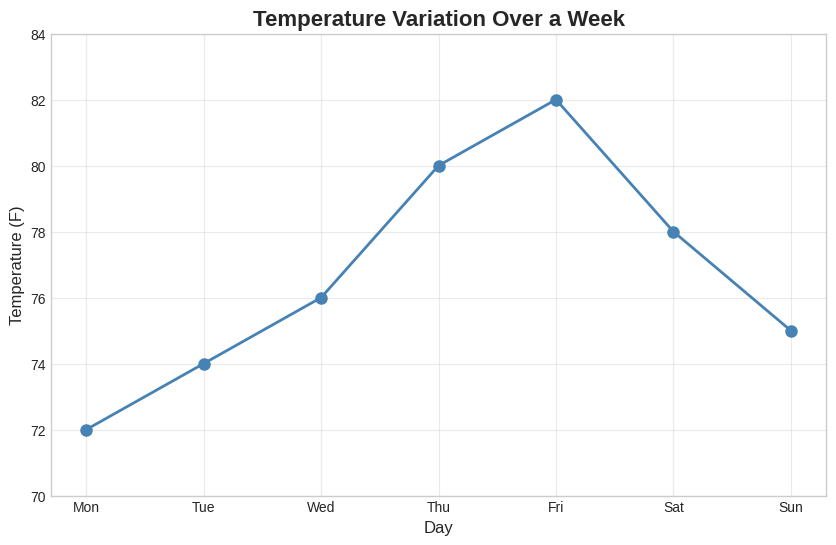

Same data, much more professional!


In [6]:
# Customized Line Plot - Professional Quality
plt.figure(figsize=(10, 6))

plt.plot(days, temperatures,
         marker='o',           # Add points at each value
         linewidth=2,          # Thicker line
         markersize=8,         # Bigger points
         color='steelblue')    # Professional color

plt.title('Temperature Variation Over a Week', fontsize=16, fontweight='bold')
plt.xlabel('Day', fontsize=12)
plt.ylabel('Temperature (F)', fontsize=12)
plt.grid(True, alpha=0.4)  # Subtle gridlines
plt.ylim(70, 84)  # Set Y-axis range to emphasize variation

plt.show()

print("Same data, much more professional!")

## Bar Charts: Comparing Categories

In [7]:
# Create sample data: Monthly Sales
months = ['January', 'February', 'March', 'April', 'May']
sales = [5000, 5500, 6200, 7000, 7500]

print("Monthly Sales Data:")
for month, sale in zip(months, sales):
    print(f"  {month}: ${sale:,}")

Monthly Sales Data:
  January: $5,000
  February: $5,500
  March: $6,200
  April: $7,000
  May: $7,500


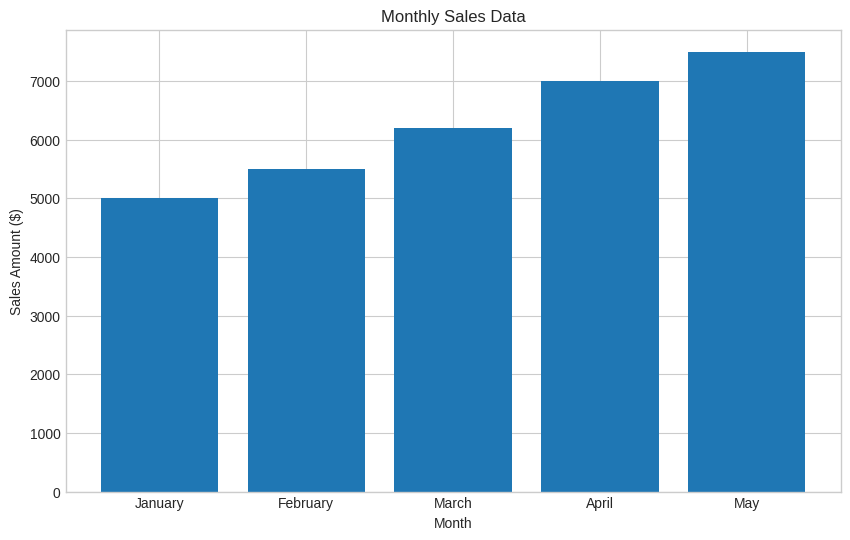

In [8]:
# ===========================================
# LIVE CODING: Basic Bar Chart
# ===========================================
# Create a bar chart with:
#   - plt.bar(categories, values)
#   - plt.title('...')
#   - plt.xlabel('...')
#   - plt.ylabel('...')
#   - plt.show()
plt.bar(months, sales)
plt.title("Monthly Sales Data")
plt.xlabel("Month")
plt.ylabel("Sales Amount ($)")
plt.show()

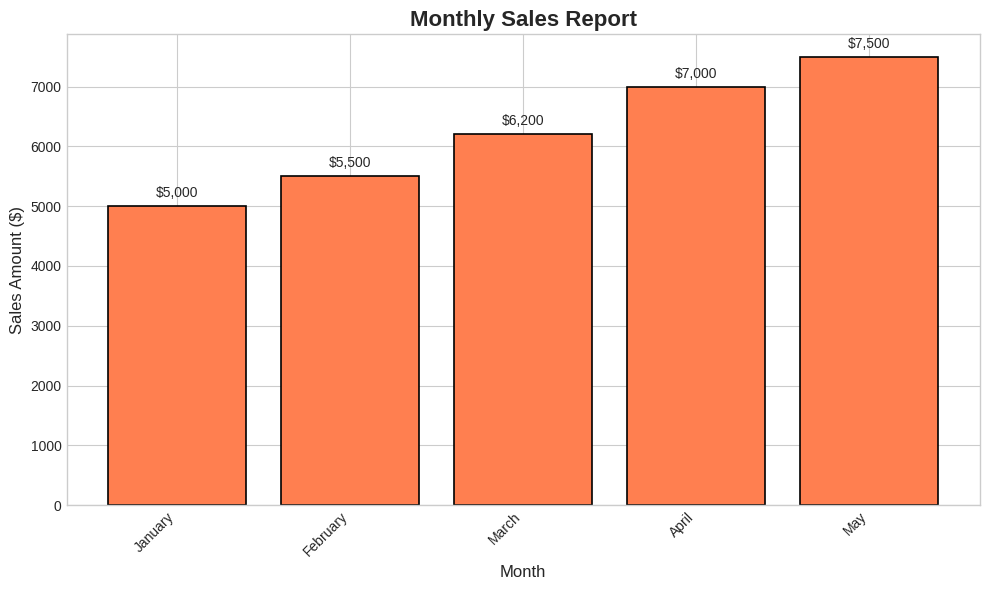

Professional bar chart with value labels!


In [9]:
# Customized Bar Chart - Presentation Ready
plt.figure(figsize=(10, 6))

bars = plt.bar(months, sales,
               color='coral',         # Nice color
               edgecolor='black',     # Border around bars
               linewidth=1.2)

plt.title('Monthly Sales Report', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Sales Amount ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotate labels if needed

# Add value labels on top of each bar
for bar, value in zip(bars, sales):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'${value:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()  # Prevent labels from being cut off
plt.show()

print("Professional bar chart with value labels!")

## Creating Multiple Plots: Subplots

Often you need to show multiple related charts together. Subplots let you create a grid of charts in one figure.

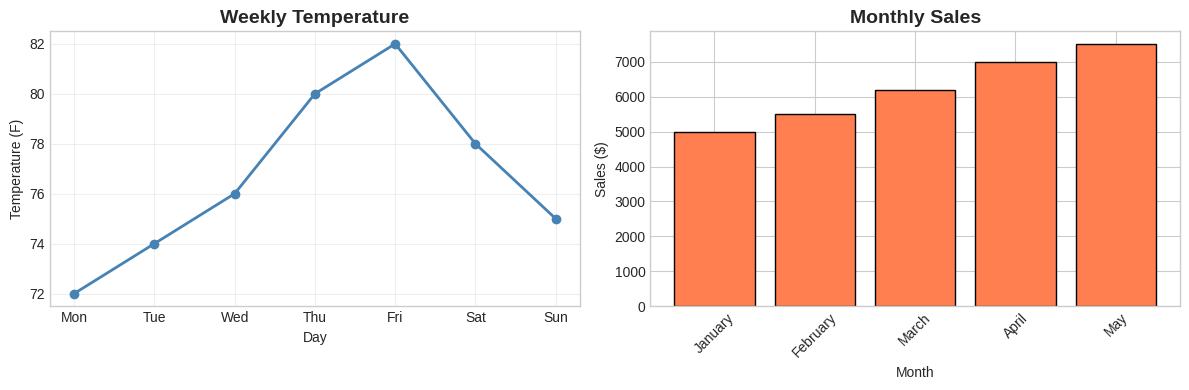

Two charts, one figure - this is how dashboards are built!


In [10]:
# Creating subplots - multiple charts in one figure
fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Left plot: Line chart (temperatures)
axes[0].plot(days, temperatures, marker='o', linewidth=2, color='steelblue')
axes[0].set_title('Weekly Temperature', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Temperature (F)')
axes[0].grid(True, alpha=0.3)

# Right plot: Bar chart (sales)
axes[1].bar(months, sales, color='coral', edgecolor='black')
axes[1].set_title('Monthly Sales', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Sales ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()  # Adjust spacing
plt.show()

print("Two charts, one figure - this is how dashboards are built!")

## Quick Practice: Matplotlib Basics (5 minutes)

**Create these two charts:**

1. **Line plot**: Daily website visitors
   - Days: Mon, Tue, Wed, Thu, Fri, Sat, Sun
   - Visitors: 150, 200, 180, 220, 300, 250, 180
   - Add title, labels, markers

2. **Bar chart**: Product sales by category
   - Categories: Electronics, Clothing, Food, Books
   - Sales: 45000, 32000, 28000, 15000
   - Add title, labels, color

In [11]:
# YOUR CODE HERE - Line Plot for Website Visitors

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
visitors = [150, 200, 180, 220, 300, 250, 180]

print("Daily website visitors:")
for day, visit in zip(days, visitors):
    print(f"  {day}: {visit}")

Daily website visitors:
  Mon: 150
  Tue: 200
  Wed: 180
  Thu: 220
  Fri: 300
  Sat: 250
  Sun: 180


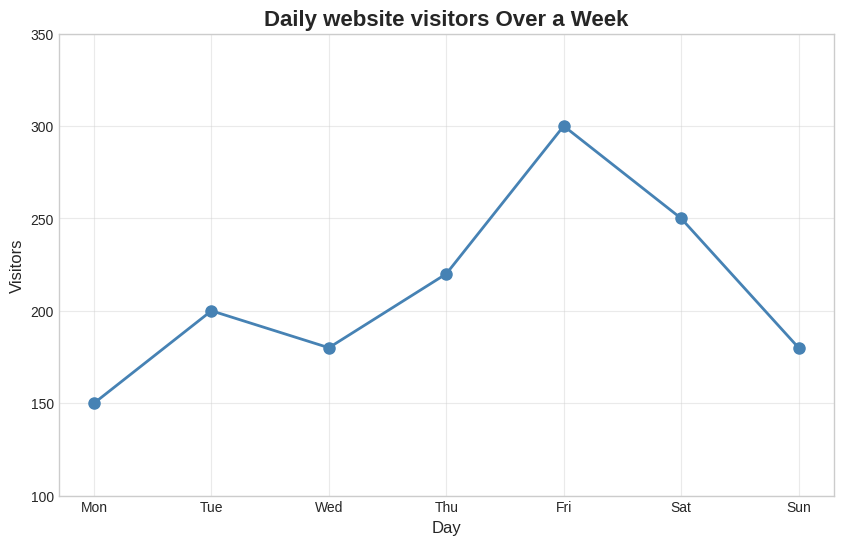

In [12]:
# Customized Line Plot - Professional Quality
plt.figure(figsize=(10, 6))

plt.plot(days, visitors,
         marker='o',           # Add points at each value
         linewidth=2,          # Thicker line
         markersize=8,         # Bigger points
         color='steelblue')    # Professional color

plt.title('Daily website visitors Over a Week', fontsize=16, fontweight='bold')
plt.xlabel('Day', fontsize=12)
plt.ylabel('Visitors', fontsize=12)
plt.grid(True, alpha=0.4)  # Subtle gridlines
plt.ylim(100, 350)  # Set Y-axis range to emphasize variation

plt.show()

In [13]:
# YOUR CODE HERE - Bar Chart for Product Sales

categories = ['Electronics', 'Clothing', 'Food', 'Books']
sales = [45000, 32000, 28000, 15000]

print("Product sales by category:")
for categorie, sale in zip(categories, sales):
    print(f"  {categorie}: ${sale:,}")

Product sales by category:
  Electronics: $45,000
  Clothing: $32,000
  Food: $28,000
  Books: $15,000


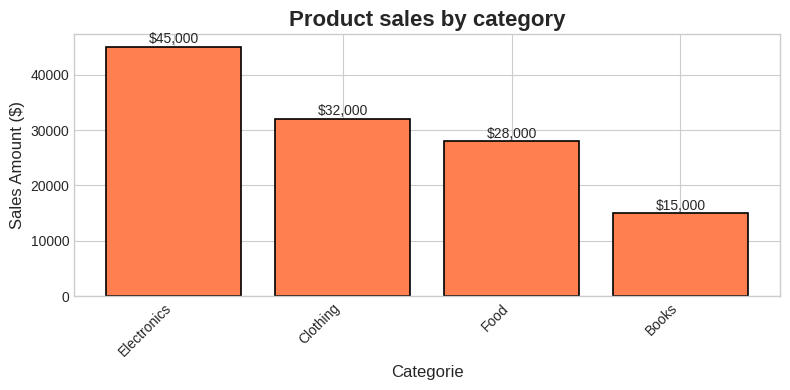

In [14]:
# Customized Bar Chart - Presentation Ready
plt.figure(figsize=(8, 4))

bars = plt.bar(categories, sales,
               color='coral',         # Nice color
               edgecolor='black',     # Border around bars
               linewidth=1.2)

plt.title('Product sales by category', fontsize=16, fontweight='bold')
plt.xlabel('Categorie', fontsize=12)
plt.ylabel('Sales Amount ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotate labels if needed

# Add value labels on top of each bar
for bar, value in zip(bars, sales):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'${value:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()  # Prevent labels from being cut off
plt.show()

---

## BREAK 1 (10 Minutes)

### What we've covered:
- Why visualization matters (Anscombe's Quartet)
- Choosing the right chart type
- Matplotlib line plots for trends
- Matplotlib bar charts for comparisons
- Creating subplots for multiple charts

### Coming up after break:
- **Seaborn** - Statistical visualization made beautiful
- Histograms, distribution plots
- Working with real datasets

---

---

# Part 3: Seaborn - Statistical Visualization

## Beautiful Charts with Less Code

---

In [15]:
# Load datasets we'll use throughout this section
tips = sns.load_dataset('tips')
mpg = sns.load_dataset('mpg')

print("Datasets loaded:")
print(f"  tips: {len(tips)} restaurant transactions (real data from a waiter in the 1990s!)")
print(f"  mpg: {len(mpg)} car fuel efficiency records")

print("\nTips dataset - first 10 rows:")
tips.head(10)

Datasets loaded:
  tips: 244 restaurant transactions (real data from a waiter in the 1990s!)
  mpg: 398 car fuel efficiency records

Tips dataset - first 10 rows:


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
6,8.77,2.00,Male,No,Sun,Dinner,2
7,26.88,3.12,Male,No,Sun,Dinner,4
8,15.04,1.96,Male,No,Sun,Dinner,2
9,14.78,3.23,Male,No,Sun,Dinner,2


## Histograms: Understanding Distributions

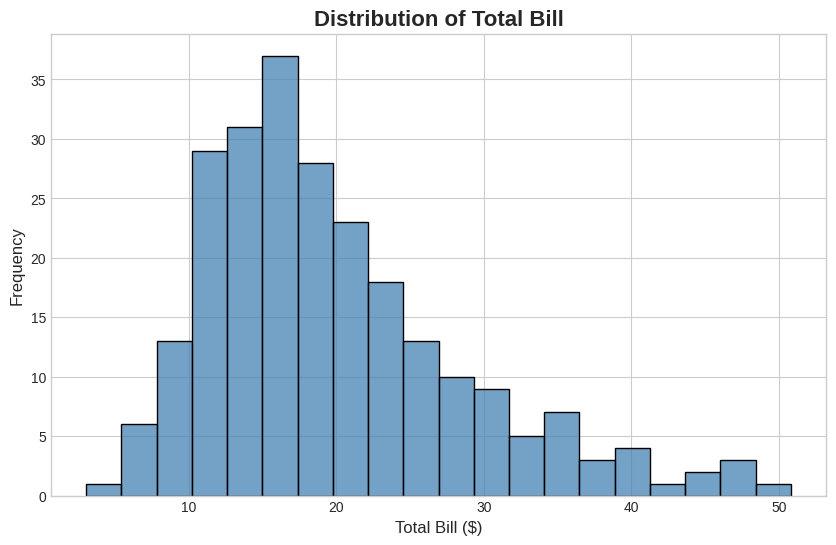

In [16]:
# ===========================================
# LIVE CODING: Basic Seaborn Histogram
# ===========================================
# Create a histogram with:
#   - plt.figure(figsize=(10, 6))
#   - sns.histplot(data=tips, x='total_bill', bins=20)
#   - plt.title('...')
#   - plt.show()
plt.figure(figsize=(10,6))

sns.histplot(data=tips, x='total_bill', bins=20, color='steelblue')

plt.title("Distribution of Total Bill", fontsize=16, fontweight='bold')
plt.xlabel('Total Bill ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.show()


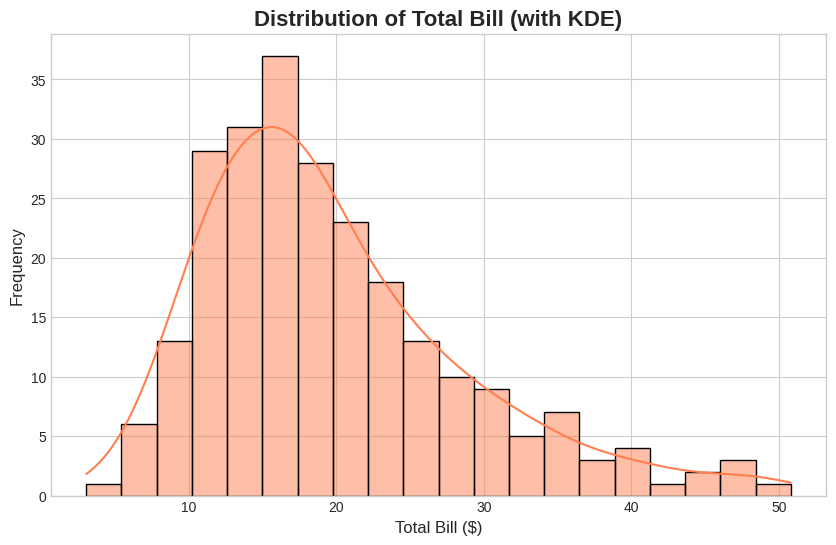

KDE (smooth curve) shows the underlying distribution shape
Notice the right skew - a long tail of expensive meals.


In [17]:
# Histogram with KDE (density curve)
plt.figure(figsize=(10, 6))

sns.histplot(data=tips, x='total_bill', bins=20, kde=True, color='coral')

plt.title('Distribution of Total Bill (with KDE)', fontsize=16, fontweight='bold')
plt.xlabel('Total Bill ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

print("KDE (smooth curve) shows the underlying distribution shape")
print("Notice the right skew - a long tail of expensive meals.")

## The Power of 'hue' - Seaborn's Killer Feature

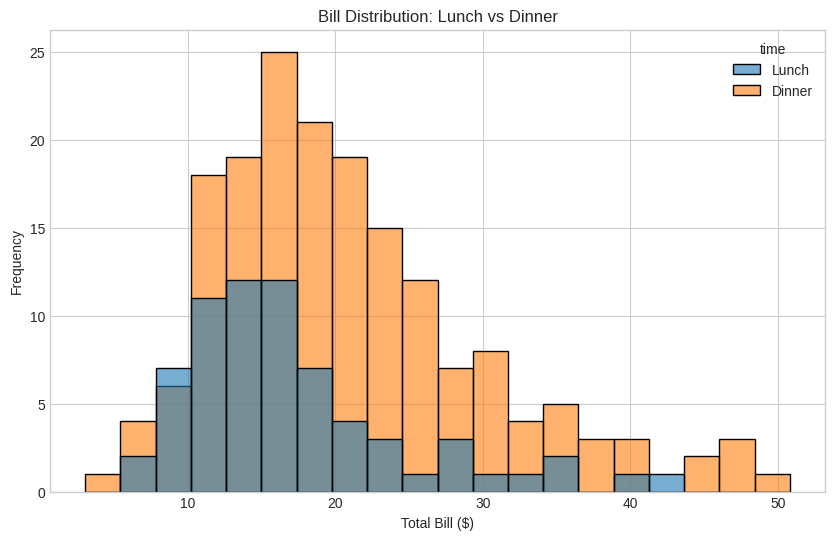

In [18]:
# ===========================================
# LIVE CODING: Histogram with hue
# ===========================================
# Add hue to compare Lunch vs Dinner:

plt.figure(figsize=(10, 6))
sns.histplot(data=tips, x='total_bill', hue='time', bins=20, alpha=0.6)
plt.title('Bill Distribution: Lunch vs Dinner')
plt.xlabel('Total Bill ($)')
plt.ylabel('Frequency')
plt.show()



## Bar Plots in Seaborn - Statistical by Default

/tmp/ipython-input-1528231693.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tips, x='day', y='tip', palette='viridis')


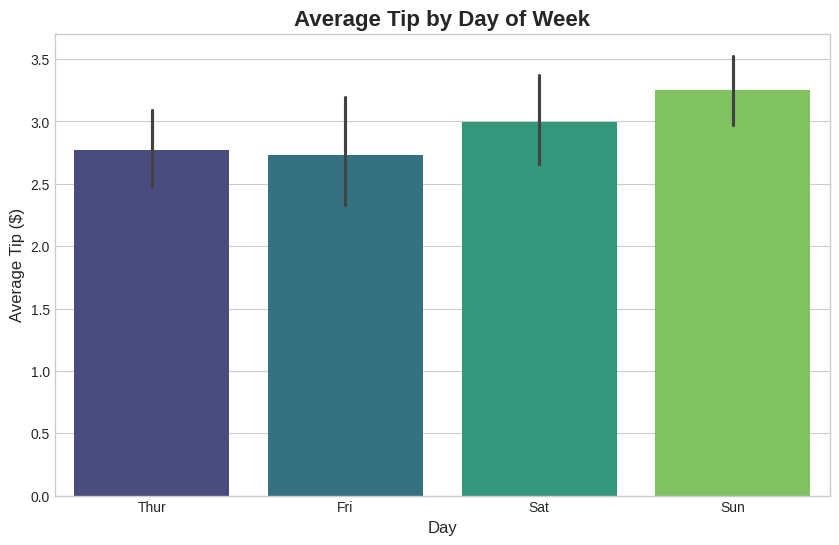

Bar height = mean, black line = 95% confidence interval
Sunday has highest mean but widest CI (more uncertainty).


In [19]:
# Seaborn barplot - shows mean with confidence interval
plt.figure(figsize=(10, 6))

sns.barplot(data=tips, x='day', y='tip', palette='viridis')

plt.title('Average Tip by Day of Week', fontsize=16, fontweight='bold')
plt.xlabel('Day', fontsize=12)
plt.ylabel('Average Tip ($)', fontsize=12)
plt.show()

print("Bar height = mean, black line = 95% confidence interval")
print("Sunday has highest mean but widest CI (more uncertainty).")

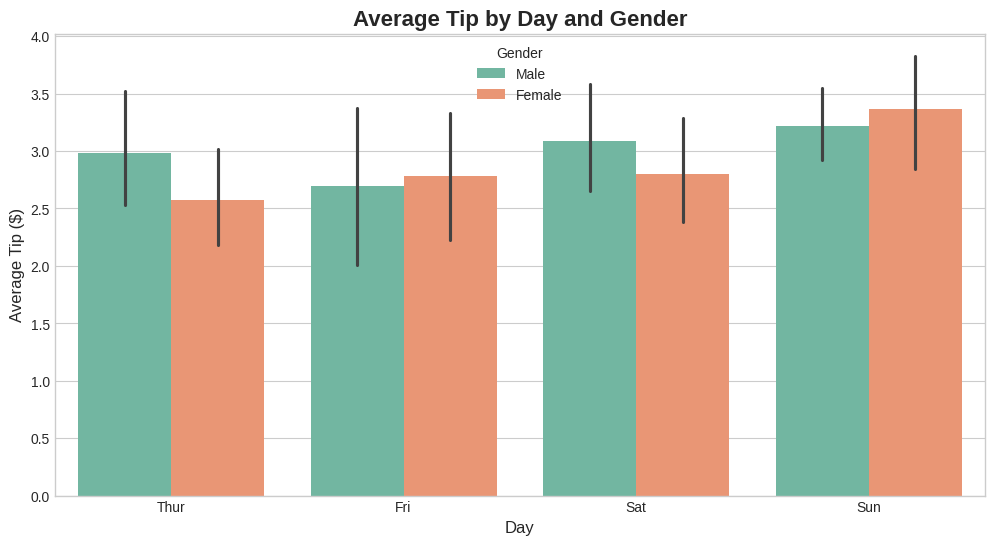

Grouped bars allow comparison across multiple dimensions.


In [20]:
# Grouped bar plot with hue - compare across two dimensions
plt.figure(figsize=(12, 6))

sns.barplot(data=tips, x='day', y='tip', hue='sex', palette='Set2')

plt.title('Average Tip by Day and Gender', fontsize=16, fontweight='bold')
plt.xlabel('Day', fontsize=12)
plt.ylabel('Average Tip ($)', fontsize=12)
plt.legend(title='Gender')
plt.show()

print("Grouped bars allow comparison across multiple dimensions.")

## Count Plots: Counting Occurrences

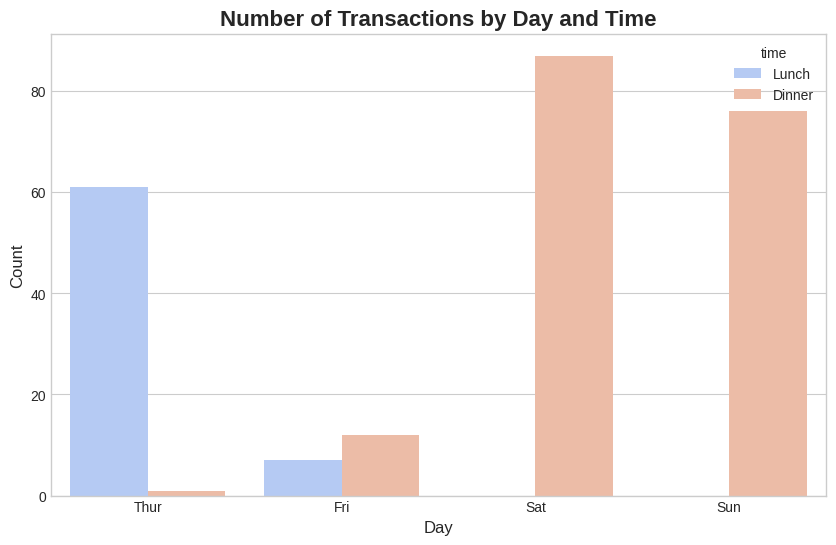

Weekend = dinner only, weekdays = mostly lunch.
This tells us about the waiter's work schedule!


In [21]:
# Count plot - counts occurrences in each category
plt.figure(figsize=(10, 6))

sns.countplot(data=tips, x='day', hue='time', palette='coolwarm')

plt.title('Number of Transactions by Day and Time', fontsize=16, fontweight='bold')
plt.xlabel('Day', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

print("Weekend = dinner only, weekdays = mostly lunch.")
print("This tells us about the waiter's work schedule!")

## Quick Practice: Seaborn Basics (5 minutes)

**Try these:**

1. Create a histogram of `tip` amounts with KDE
2. Create a histogram of `tip` with hue by `smoker` (Yes/No)
3. Create a barplot of average `total_bill` by `day`

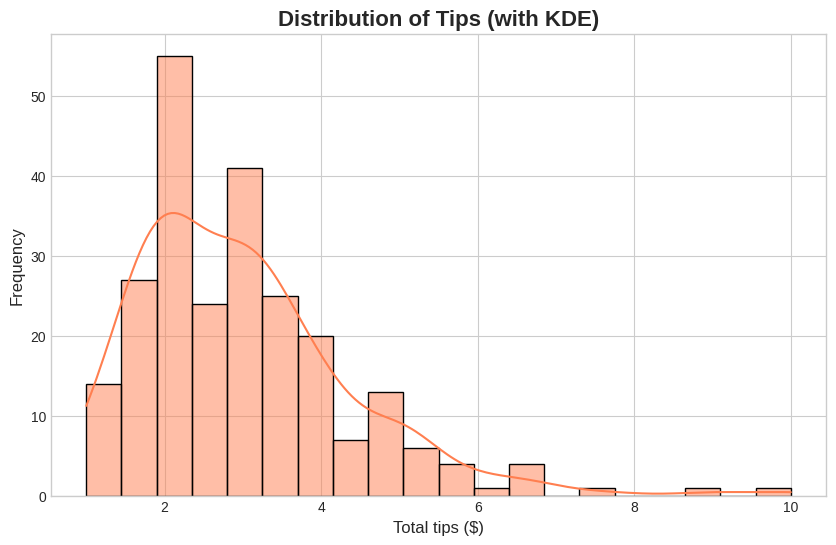

In [22]:
# YOUR CODE HERE - Histogram of tip with KDE

plt.figure(figsize=(10, 6))

sns.histplot(data=tips, x='tip', bins=20, kde=True, color='coral')

plt.title('Distribution of Tips (with KDE)', fontsize=16, fontweight='bold')
plt.xlabel('Total tips ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()


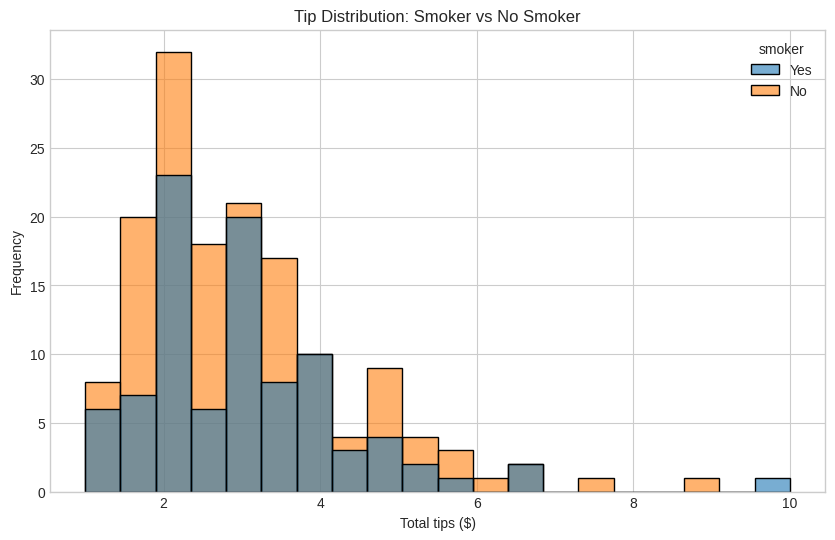

In [23]:
# YOUR CODE HERE - Histogram of tip with hue='smoker'
plt.figure(figsize=(10, 6))
sns.histplot(data=tips, x='tip', hue='smoker', bins=20, alpha=0.6)
plt.title('Tip Distribution: Smoker vs No Smoker')
plt.xlabel('Total tips ($)')
plt.ylabel('Frequency')
plt.show()

/tmp/ipython-input-2517890566.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tips, x='day', y='total_bill', palette='Blues_d')


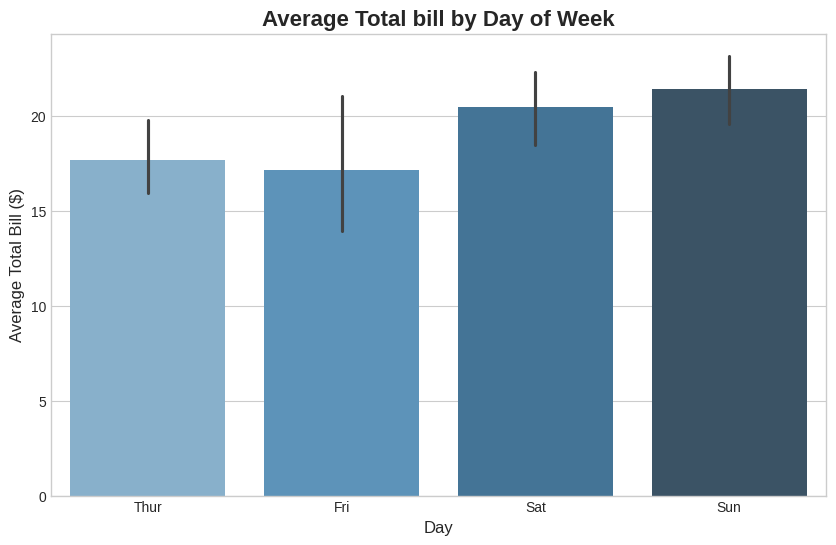

In [24]:
# YOUR CODE HERE - Barplot of total_bill by day

plt.figure(figsize=(10, 6))

sns.barplot(data=tips, x='day', y='total_bill', palette='Blues_d')

plt.title('Average Total bill by Day of Week', fontsize=16, fontweight='bold')
plt.xlabel('Day', fontsize=12)
plt.ylabel('Average Total Bill ($)', fontsize=12)
plt.show()



## Solutions

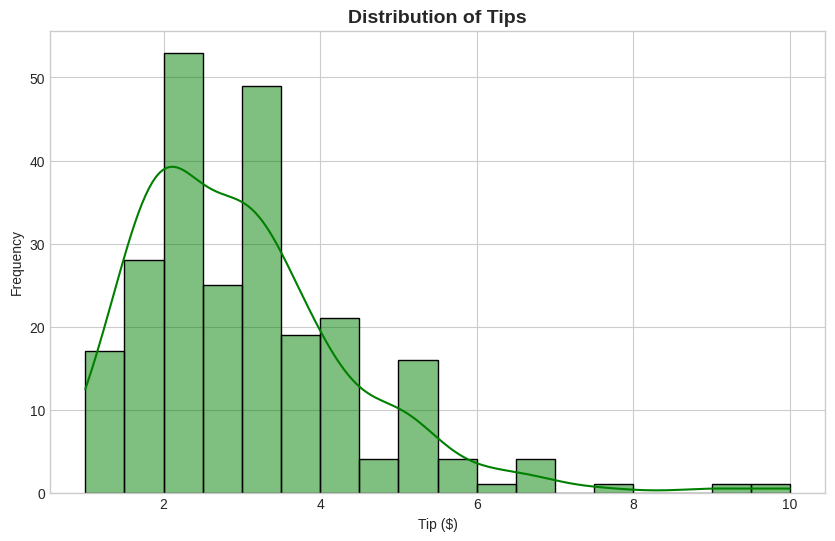

In [25]:
# Solution 1: Histogram of tip with KDE
plt.figure(figsize=(10, 6))
sns.histplot(data=tips, x='tip', kde=True, color='green')
plt.title('Distribution of Tips', fontsize=14, fontweight='bold')
plt.xlabel('Tip ($)')
plt.ylabel('Frequency')
plt.show()

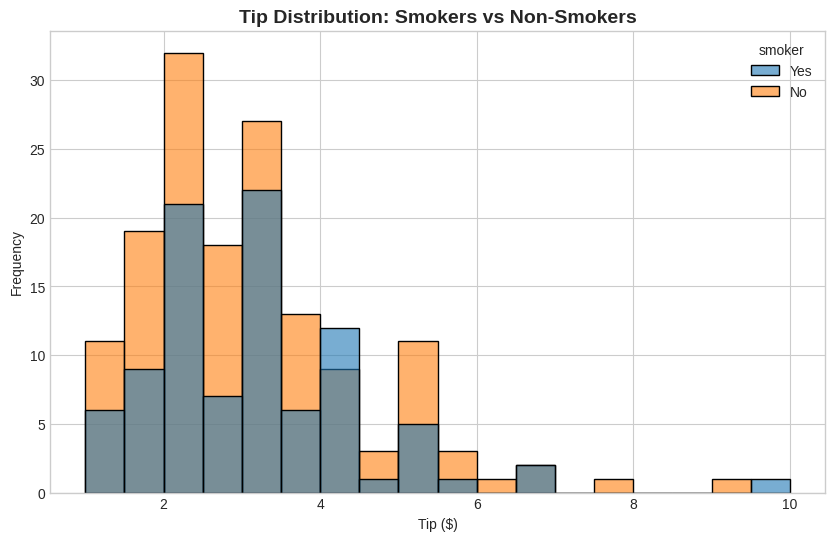

In [26]:
# Solution 2: Histogram with hue='smoker'
plt.figure(figsize=(10, 6))
sns.histplot(data=tips, x='tip', hue='smoker', alpha=0.6)
plt.title('Tip Distribution: Smokers vs Non-Smokers', fontsize=14, fontweight='bold')
plt.xlabel('Tip ($)')
plt.ylabel('Frequency')
plt.show()

/tmp/ipython-input-2928046109.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tips, x='day', y='total_bill', palette='Blues_d')


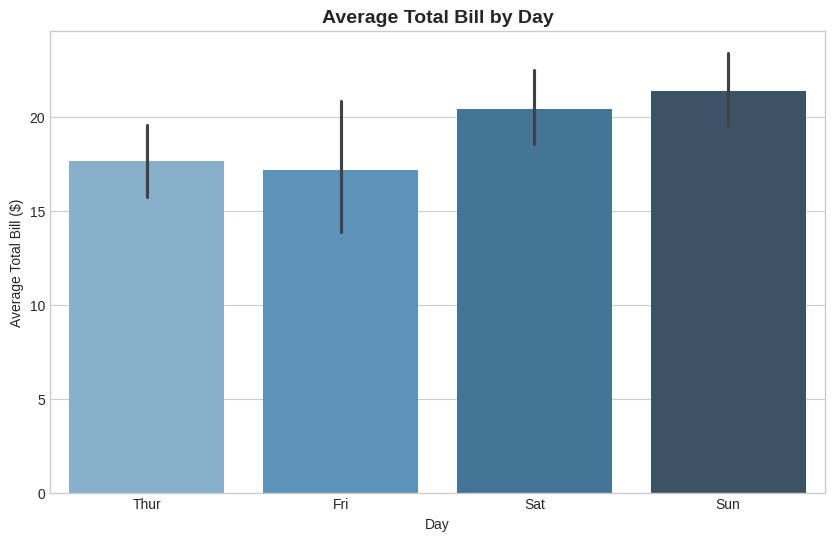

In [27]:
# Solution 3: Barplot of total_bill by day
plt.figure(figsize=(10, 6))
sns.barplot(data=tips, x='day', y='total_bill', palette='Blues_d')
plt.title('Average Total Bill by Day', fontsize=14, fontweight='bold')
plt.xlabel('Day')
plt.ylabel('Average Total Bill ($)')
plt.show()

---

# Part 4: Scatter Plots and Relationships

## Exploring How Variables Connect

---

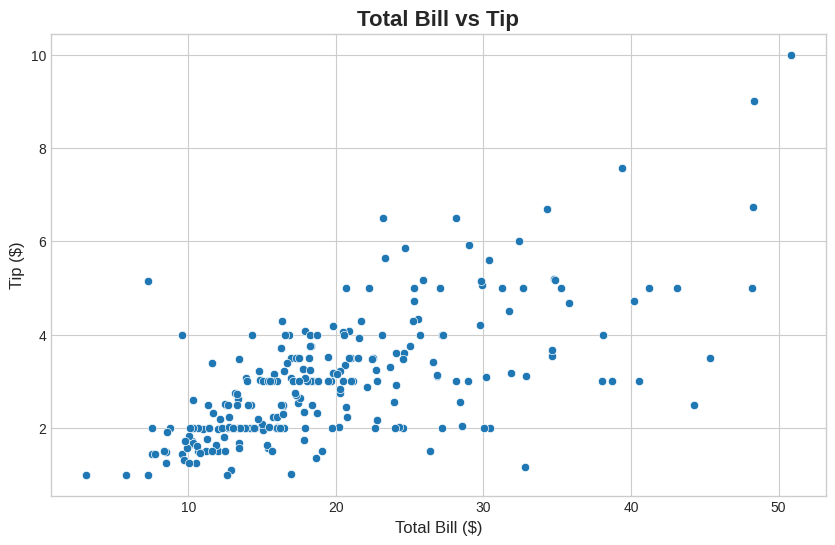

In [28]:
# ===========================================
# LIVE CODING: Basic Scatter Plot
# ===========================================
# Create a scatter plot with:
#   - plt.figure(figsize=(10, 6))
#   - sns.scatterplot(data=tips, x='total_bill', y='tip')
#   - plt.title('...')
#   - plt.show()

plt.figure(figsize=(10, 6))

sns.scatterplot(data=tips, x='total_bill', y='tip')
plt.title("Total Bill vs Tip", fontsize=16, fontweight='bold')
plt.xlabel("Total Bill ($)", fontsize=12)
plt.ylabel("Tip ($)", fontsize=12)
plt.show()

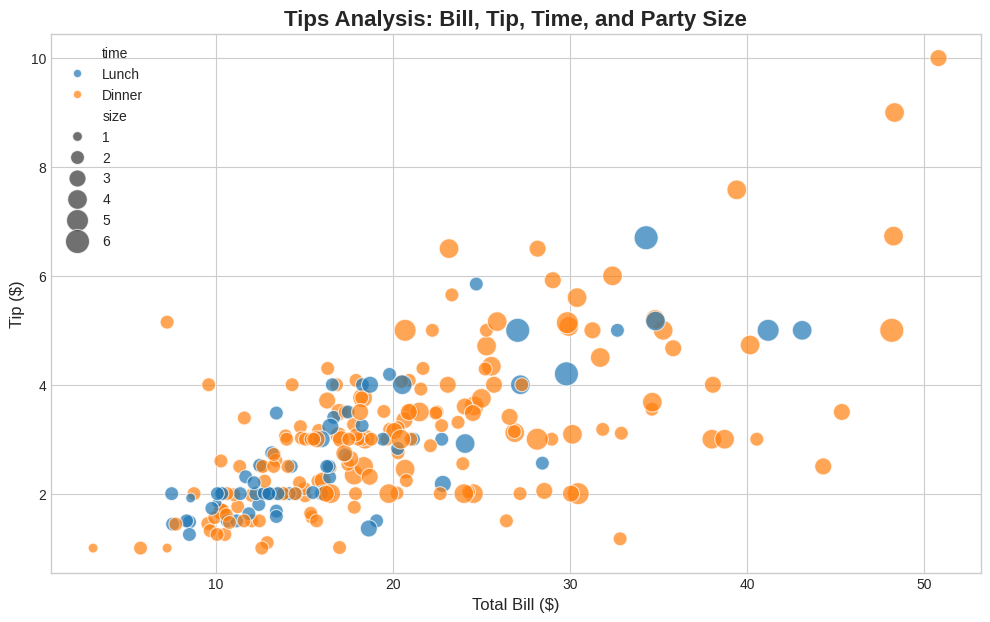

Four dimensions of data in one plot!
  X = Total Bill, Y = Tip, Color = Time, Size = Party Size


In [29]:
# Scatter plot with hue and size - FOUR dimensions!
plt.figure(figsize=(12, 7))

sns.scatterplot(data=tips, x='total_bill', y='tip',
                hue='time',           # Color by lunch/dinner
                size='size',          # Point size by party size
                sizes=(50, 300),      # Size range
                alpha=0.7)            # Transparency

plt.title('Tips Analysis: Bill, Tip, Time, and Party Size', fontsize=16, fontweight='bold')
plt.xlabel('Total Bill ($)', fontsize=12)
plt.ylabel('Tip ($)', fontsize=12)
plt.show()

print("Four dimensions of data in one plot!")
print("  X = Total Bill, Y = Tip, Color = Time, Size = Party Size")

## Regression Plots: Adding Trend Lines

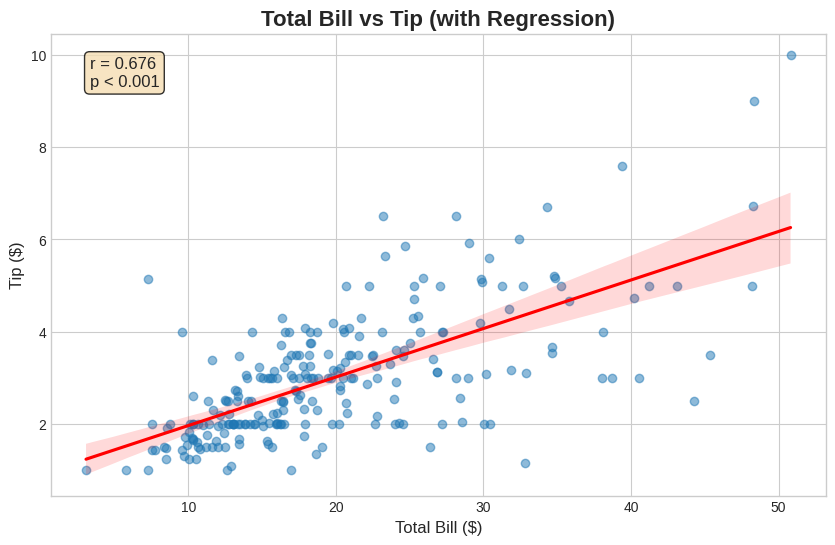

Correlation: r = 0.676 (moderate-strong positive)
P-value: 6.69e-34 (highly significant - not due to chance)


In [30]:
# Regression plot with trend line and statistics
plt.figure(figsize=(10, 6))

sns.regplot(data=tips, x='total_bill', y='tip',
            scatter_kws={'alpha': 0.5},
            line_kws={'color': 'red'})

# Calculate and display correlation
r, p = stats.pearsonr(tips['total_bill'], tips['tip'])
plt.text(0.05, 0.95, f'r = {r:.3f}\np < 0.001',
         transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.title('Total Bill vs Tip (with Regression)', fontsize=16, fontweight='bold')
plt.xlabel('Total Bill ($)', fontsize=12)
plt.ylabel('Tip ($)', fontsize=12)
plt.show()

print(f"Correlation: r = {r:.3f} (moderate-strong positive)")
print(f"P-value: {p:.2e} (highly significant - not due to chance)")

## Quick Practice: Scatter Plots (3 minutes)

**Create a scatter plot:**
- X: total_bill
- Y: tip  
- Color by: day
- Add a title

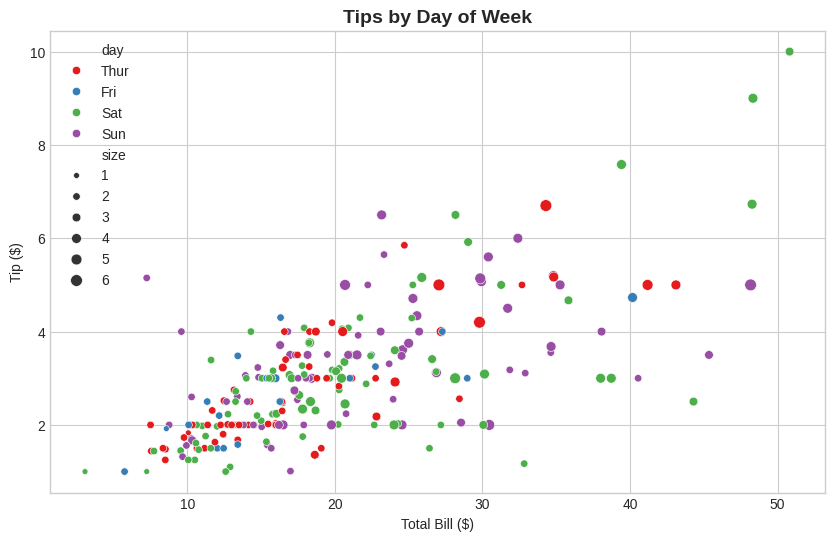

In [31]:
# YOUR CODE HERE - Scatter plot colored by day
plt.figure(figsize=(10,6))
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='day', size='size', palette='Set1')
plt.title("Tips by Day of Week", fontsize=14, fontweight='bold')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.show()


---

## BREAK 2 (10 Minutes)

### What we've covered:
- Seaborn basics and the power of 'hue'
- Histograms for distribution analysis
- Statistical bar plots with confidence intervals
- Scatter plots for relationships
- Regression lines with correlation statistics

### Coming up after break:
- **Box plots** - Comparing distributions across groups
- **Pair plots** - Exploring many relationships at once
- **Heatmaps** - Correlation matrices
- **Mini-project** - Build a complete dashboard!

---

**Key Shift:** Before break, we looked at how two variables *relate*. After break, we'll compare how *distributions differ* across groups.

---

## BREAK 2 (10 Minutes)

### What we've covered:
- Seaborn basics and the power of 'hue'
- Histograms for distribution analysis
- Statistical bar plots with confidence intervals
- Scatter plots for relationships
- Regression lines with correlation statistics

### Coming up after break:
- **Box plots** - Comparing distributions across groups
- **Pair plots** - Exploring many relationships at once
- **Heatmaps** - Correlation matrices
- **Mini-project** - Build a complete dashboard!

---

---

# Part 5: Box Plots and Distribution Comparison

## Seeing the Full Picture

---

## Box Plot Anatomy

```
HOW TO READ A BOX PLOT:

           o  <- outlier (beyond 1.5 x IQR)
           |
           |
       ----+----  <- upper whisker (max non-outlier)
           |
       +---+---+
       |   |   |  <- Q3 (75th percentile)
       |   |   |
       |---|---|  <- MEDIAN (50th percentile)
       |   |   |
       |   |   |  <- Q1 (25th percentile)
       +---+---+
           |
       ----+----  <- lower whisker (min non-outlier)
           |
           o  <- outlier


    THE BOX = middle 50% of data (IQR = Interquartile Range)
    THE LINE = median (middle value)
    THE WHISKERS = range of non-outlier data
    THE DOTS = outliers (unusual values)
```

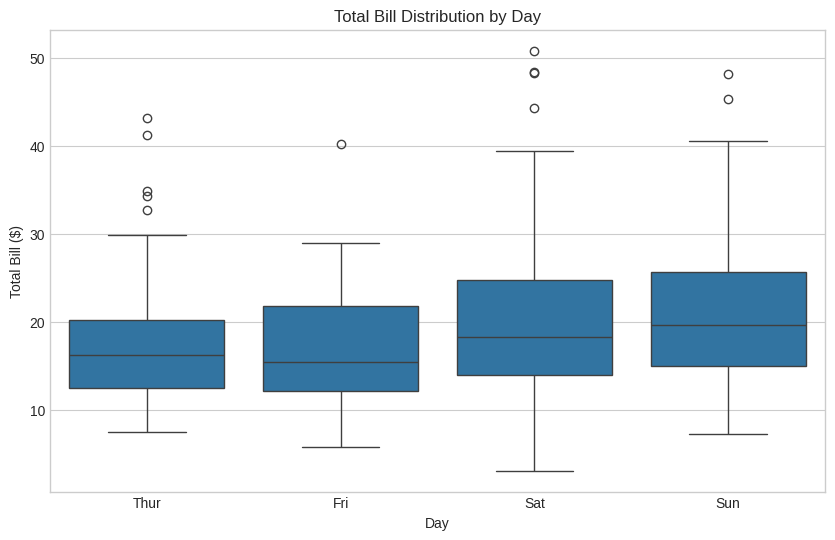

In [32]:
# ===========================================
# LIVE CODING: Basic Box Plot
# ===========================================
# Create a box plot with:
#   - plt.figure(figsize=(10, 6))
#   - sns.boxplot(data=tips, x='day', y='total_bill')
#   - plt.title('...')
#   - plt.show()

plt.figure(figsize=(10, 6))

sns.boxplot(data=tips, x='day', y='total_bill')

plt.title('Total Bill Distribution by Day')
plt.xlabel('Day')
plt.ylabel('Total Bill ($)')
plt.show()

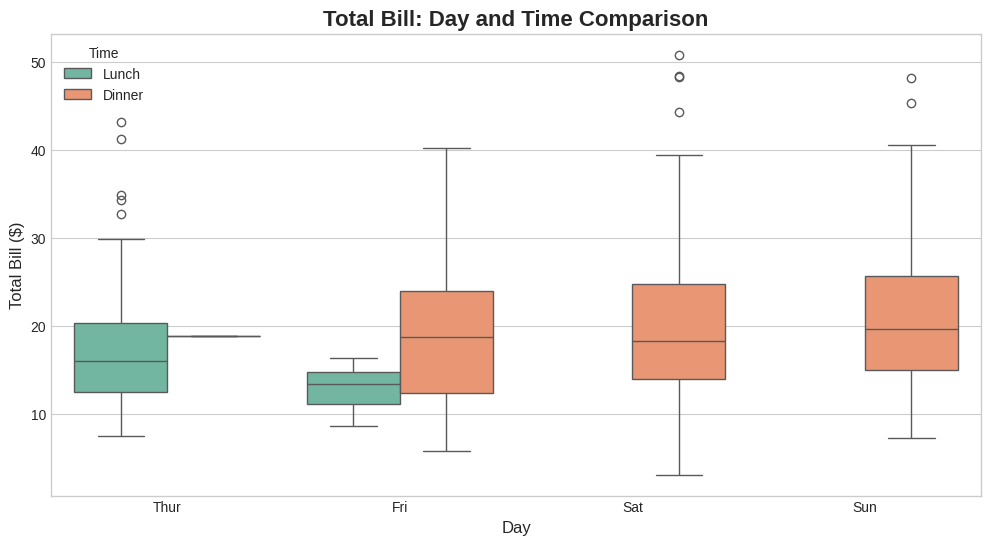

Dinner bills are consistently higher than lunch bills.
Weekend dinner bills have the most variation.


In [33]:
# Box plot with hue - comparing sub-groups
plt.figure(figsize=(12, 6))

sns.boxplot(data=tips, x='day', y='total_bill', hue='time', palette='Set2')

plt.title('Total Bill: Day and Time Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Day', fontsize=12)
plt.ylabel('Total Bill ($)', fontsize=12)
plt.legend(title='Time')
plt.show()

print("Dinner bills are consistently higher than lunch bills.")
print("Weekend dinner bills have the most variation.")

## Comparing Multiple Scores with Box Plots

In [34]:
# Create sample data: Movie scores (simulating Critic vs Audience)
np.random.seed(42)
movie_data = pd.DataFrame({
    'movie': [f'Movie_{i}' for i in range(50)],
    'critic_score': np.random.normal(70, 15, 50).clip(0, 100),
    'audience_score': np.random.normal(65, 20, 50).clip(0, 100)
})

print("Movie scores data (wide format):")
movie_data.head()

Movie scores data (wide format):


,movie,critic_score,audience_score
0,Movie_0,77.450712,71.481679
1,Movie_1,67.926035,57.298354
2,Movie_2,79.715328,51.461560
3,Movie_3,92.845448,77.233526
4,Movie_4,66.487699,85.619990


In [35]:
# Melt the data to compare scores   #appendear score de audiencia abajo de critic_score
scores_melted = pd.melt(movie_data,
                         id_vars=['movie'],
                         value_vars=['critic_score', 'audience_score'],
                         var_name='Score Type',
                         value_name='Score')

print("Melted data (long format) - ready for box plot:")
print(scores_melted.head(10))

Melted data (long format) - ready for box plot:
     movie    Score Type      Score
0  Movie_0  critic_score  77.450712
1  Movie_1  critic_score  67.926035
2  Movie_2  critic_score  79.715328
3  Movie_3  critic_score  92.845448
4  Movie_4  critic_score  66.487699
5  Movie_5  critic_score  66.487946
6  Movie_6  critic_score  93.688192
7  Movie_7  critic_score  81.511521
8  Movie_8  critic_score  62.957884
9  Movie_9  critic_score  78.138401


/tmp/ipython-input-2044234696.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=scores_melted, x='Score Type', y='Score', palette='pastel')


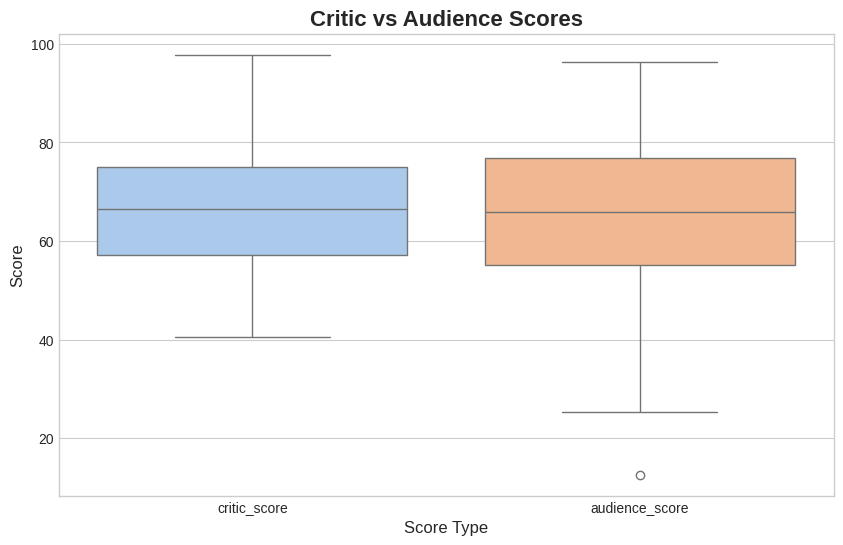

Critics score slightly higher on average.
Audiences have more variability (wider box and whiskers).


In [36]:
# Compare score distributions with box plot
plt.figure(figsize=(10, 6))

sns.boxplot(data=scores_melted, x='Score Type', y='Score', palette='pastel')

plt.title('Critic vs Audience Scores', fontsize=16, fontweight='bold')
plt.xlabel('Score Type', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.show()

print("Critics score slightly higher on average.")
print("Audiences have more variability (wider box and whiskers).")

---

# Part 6: Advanced Visualizations

## Pair Plots and Heatmaps

---

In [41]:
#Es un conjunto de datos de autos (mayormente años 70–80) y mide eficiencia de combustible. Ya viene en seaborn.

mpg_subset .head()

,mpg,horsepower,weight,acceleration,origin
0,18.0,130.0,3504,12.0,usa
1,15.0,165.0,3693,11.5,usa
2,18.0,150.0,3436,11.0,usa
3,16.0,150.0,3433,12.0,usa
4,17.0,140.0,3449,10.5,usa


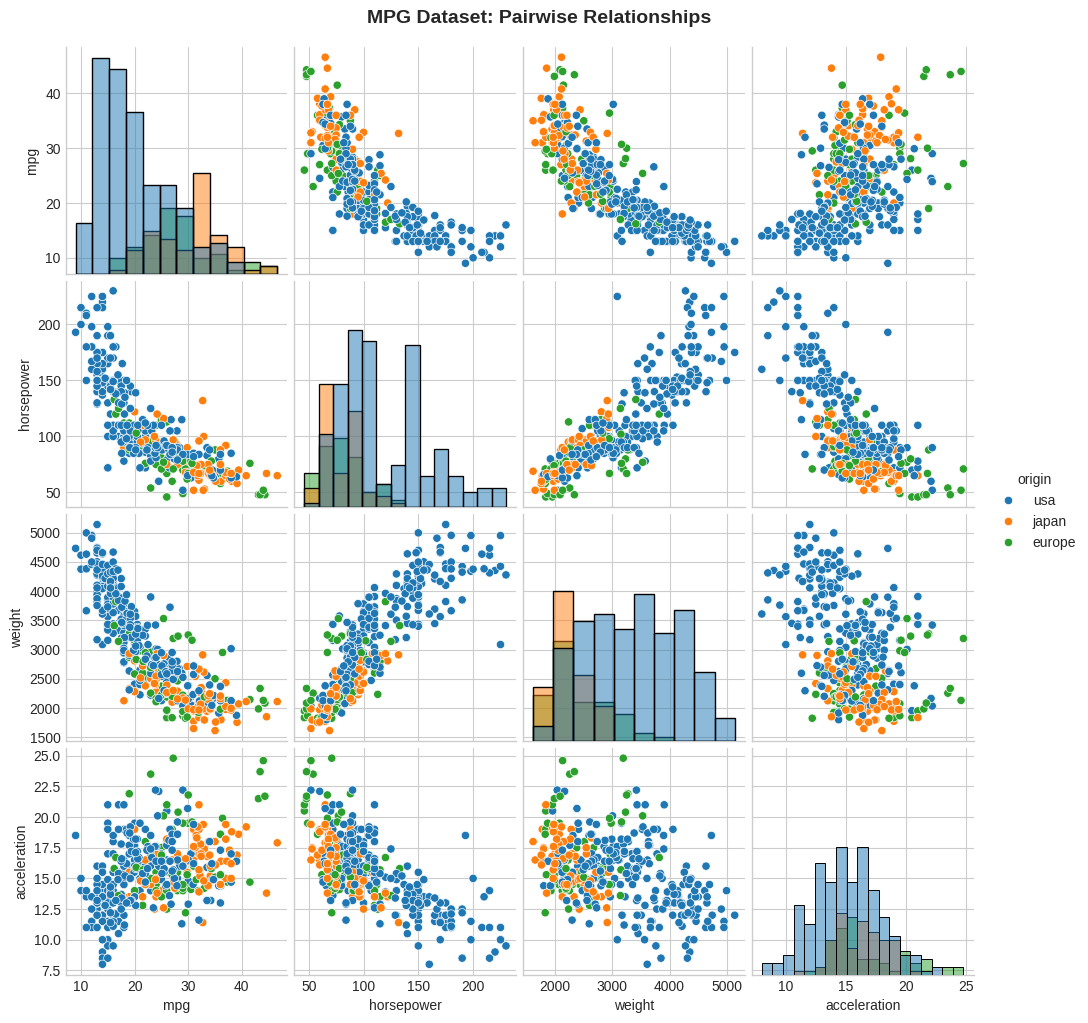

Pair plot shows ALL relationships at once!
  Diagonal = distribution of each variable
  Off-diagonal = scatter plots between variables
  Colors = origin (USA, Japan, Europe)


In [39]:
# Pair plot - all pairwise relationships at once
# Using subset of columns for cleaner display
mpg_subset = mpg[['mpg', 'horsepower', 'weight', 'acceleration', 'origin']].dropna()

sns.pairplot(mpg_subset, hue='origin', diag_kind='hist', height=2.5)

plt.suptitle('MPG Dataset: Pairwise Relationships', y=1.02, fontsize=14, fontweight='bold')
plt.show()

print("Pair plot shows ALL relationships at once!")
print("  Diagonal = distribution of each variable")
print("  Off-diagonal = scatter plots between variables")
print("  Colors = origin (USA, Japan, Europe)")

## Heatmaps: Correlation Matrices

In [42]:
# Calculate correlation matrix
numeric_cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']
corr_matrix = mpg[numeric_cols].corr()

print("Correlation Matrix (raw numbers):")
corr_matrix.round(2)

Correlation Matrix (raw numbers):


,mpg,cylinders,displacement,horsepower,weight,acceleration
mpg,1.00,-0.78,-0.80,-0.78,-0.83,0.42
cylinders,-0.78,1.00,0.95,0.84,0.90,-0.51
displacement,-0.80,0.95,1.00,0.90,0.93,-0.54
horsepower,-0.78,0.84,0.90,1.00,0.86,-0.69
weight,-0.83,0.90,0.93,0.86,1.00,-0.42
acceleration,0.42,-0.51,-0.54,-0.69,-0.42,1.00


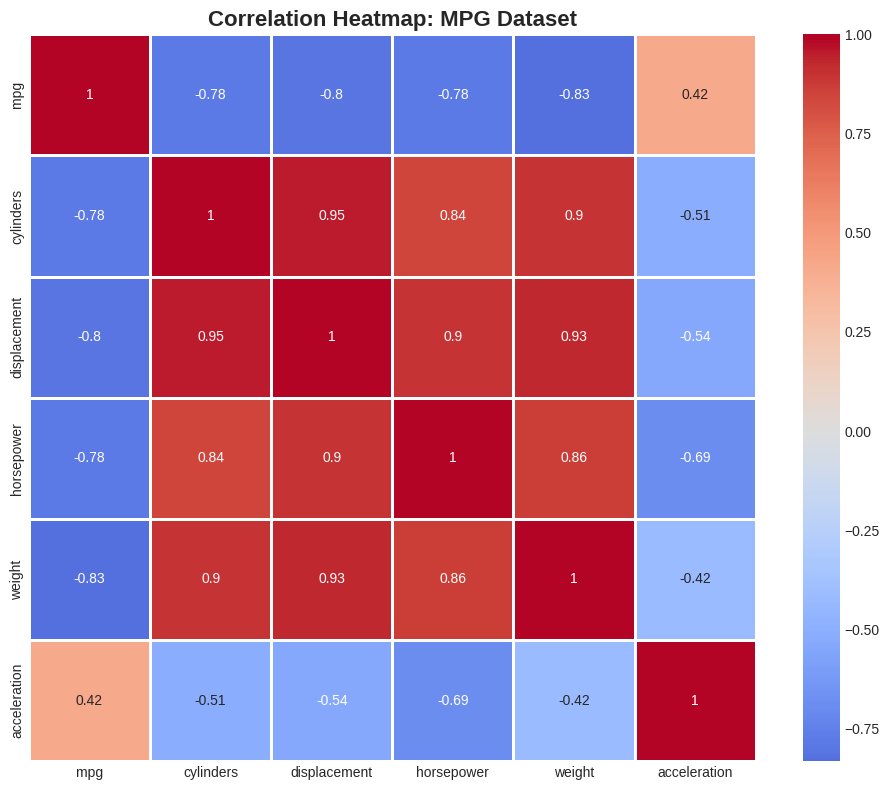

In [43]:
# ===========================================
# LIVE CODING: Heatmap
# ===========================================
# Create a heatmap with:
#   - plt.figure(figsize=(10, 8))
#   - sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
#   - plt.title('...')
#   - plt.show()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
             annot=True, # Show numbers
             cmap='coolwarm', # Red-white-blue color scheme
             center=0, # White at 0
             square=True, # Squaare cells
             linewidths=1 # Cell borders
            )

plt.title("Correlation Heatmap: MPG Dataset", fontsize=16, fontweight='bold')
plt.tight_layout()

plt.savefig('filename.png', dpi=300, bbox_inches='tight')

plt.show()



---

# Part 7: Mini-Project - Complete Dashboard

## Put It All Together

---

## Your Task (15 minutes)

```
CREATE A 4-PANEL DASHBOARD:

    Using the mpg dataset, create:
    
    1. TOP-LEFT: Histogram of MPG with KDE
       - Show the distribution shape
       - Add title and labels
    
    2. TOP-RIGHT: Box plot of MPG by origin
       - Compare USA, Japan, Europe
       - Add title and labels
    
    3. BOTTOM-LEFT: Scatter plot of weight vs MPG
       - Color by origin
       - Add title and labels
    
    4. BOTTOM-RIGHT: Correlation heatmap
       - Include mpg, horsepower, weight, acceleration
       - Add annotations
    
    
    HINTS:
    - Use fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    - Access subplots with axes[row, col]
    - Don't forget plt.tight_layout()
```

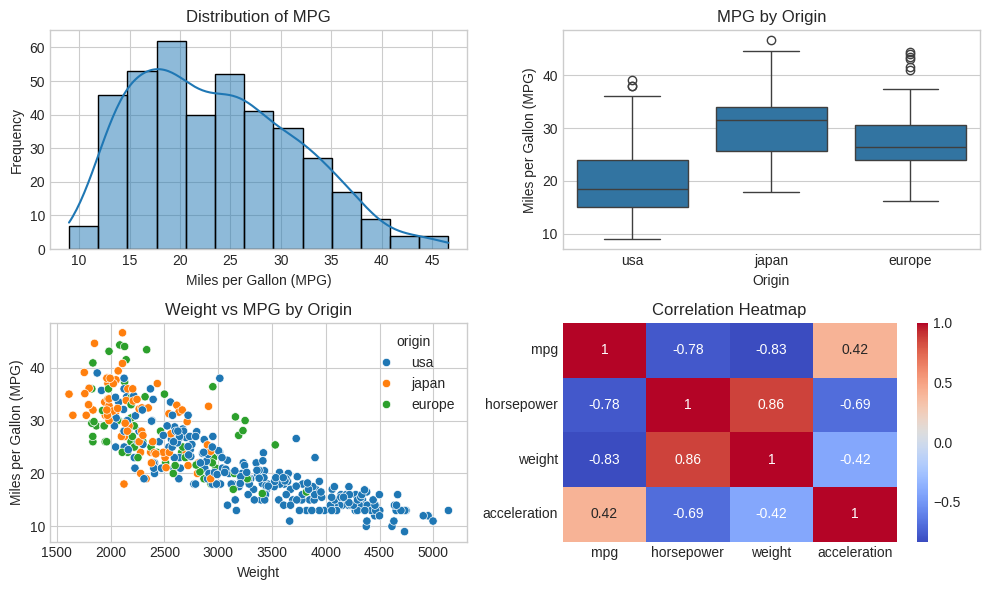

1️⃣ Distribution of MPG
Se muestra concentración principal entre 15–30 mpg y ligera asimetría a la derecha.
La eficiencia es moderada en su mayoría , con algunos modelos más eficientes en la cola superior.
No se observa multimodalidad, aunque la variable no es perfectamente simétrica.

2️⃣ MPG by Origin
Japón y Europa presentan mayor eficiencia promedio, mientras que USA muestra menor MPG y mayor dispersión.
Se presumen diferencias estructurales en diseño, especialmente relacionadas con el peso de los vehículos.

3️⃣ Weight vs MPG
Se observa una relación negativa fuerte: a mayor peso, menor eficiencia.
Los autos japoneses tiene menor peso y mayor MPG, mientras que los estadounidenses predominan en el rango opuesto.

4️⃣ Correlation Heatmap
mpg vs weight → fuerte negativa -0.83
mpg vs horsepower → fuerte negativa -0.78
     --> Los autos más pesados tienden a tener mayor potencia y menor eficiencia.

weight vs horsepower → positiva +0.86
     --> L En modelado, pueden generar colinealid

In [55]:
# YOUR DASHBOARD CODE HERE

# import seaborn as sns
# import matplotlib.pyplot as plt

# # Load dataset
# df = sns.load_dataset("mpg")

#(todo esto ya lo tengo de los comandos anteriores)

# Create 4-panel dashboard
fig, axes = plt.subplots(2, 2, figsize=(10, 6))   #figsize=(14, 12))  no me gusta queda muy grande

# ---------------------------
# 1️⃣ TOP-LEFT: Histogram + KDE
# ---------------------------
sns.histplot(df["mpg"], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Distribution of MPG")
axes[0, 0].set_xlabel("Miles per Gallon (MPG)")
axes[0, 0].set_ylabel("Frequency")

# ---------------------------
# 2️⃣ TOP-RIGHT: Boxplot by Origin
# ---------------------------
sns.boxplot(data=df, x="origin", y="mpg", ax=axes[0, 1])
axes[0, 1].set_title("MPG by Origin")
axes[0, 1].set_xlabel("Origin")
axes[0, 1].set_ylabel("Miles per Gallon (MPG)")

# ---------------------------
# 3️⃣ BOTTOM-LEFT: Scatter plot
# ---------------------------
sns.scatterplot(data=df, x="weight", y="mpg", hue="origin", ax=axes[1, 0])
axes[1, 0].set_title("Weight vs MPG by Origin")
axes[1, 0].set_xlabel("Weight")
axes[1, 0].set_ylabel("Miles per Gallon (MPG)")

# ---------------------------
# 4️⃣ BOTTOM-RIGHT: Correlation Heatmap
# ---------------------------
corr = df[["mpg", "horsepower", "weight", "acceleration"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", ax=axes[1, 1])
axes[1, 1].set_title("Correlation Heatmap")

# Adjust layout to Prevent overlap
plt.tight_layout()

# Show
plt.show()

print ('''1️⃣ Distribution of MPG
Se muestra concentración principal entre 15–30 mpg y ligera asimetría a la derecha.
La eficiencia es moderada en su mayoría , con algunos modelos más eficientes en la cola superior.
No se observa multimodalidad, aunque la variable no es perfectamente simétrica.''')

print()

print ('''2️⃣ MPG by Origin
Japón y Europa presentan mayor eficiencia promedio, mientras que USA muestra menor MPG y mayor dispersión.
Se presumen diferencias estructurales en diseño, especialmente relacionadas con el peso de los vehículos.''')

print()

print ('''3️⃣ Weight vs MPG
Se observa una relación negativa fuerte: a mayor peso, menor eficiencia.
Los autos japoneses tiene menor peso y mayor MPG, mientras que los estadounidenses predominan en el rango opuesto.''')

print()

print ('''4️⃣ Correlation Heatmap
mpg vs weight → fuerte negativa -0.83
mpg vs horsepower → fuerte negativa -0.78
     --> Los autos más pesados tienden a tener mayor potencia y menor eficiencia.

weight vs horsepower → positiva +0.86
     --> L En modelado, pueden generar colinealidad si se incluyen juntos..''')

print()

print ('''🎯 Conclusion
El peso emerge como el principal determinante de la eficiencia de combustible.
Las diferencias regionales parecen explicarse por variaciones estructurales en peso y potencia.
Un modelo predictivo de mpg debería incluir al menos weight, horsepower y origin, evaluando posible multicolinealidad.''')


## Saving Your Visualizations

**Important:** After creating a visualization, you'll often need to save it for reports or presentations.

```python
# After creating your figure:
plt.savefig('filename.png', dpi=300, bbox_inches='tight')

# Options:
#   'filename.png' - High quality PNG image
#   'filename.pdf' - Vector PDF (best for print)
#   'filename.svg' - Vector SVG (web/edit)
#   dpi=300 - Resolution (300 is publication quality)
#   bbox_inches='tight' - Prevents labels from being cut off
```

---

# Wrap Up

---

## Quick Reference: Chart Selection Guide

```python
# TRENDS OVER TIME
plt.plot(x, y, marker='o')  # Line plot

# COMPARING CATEGORIES
plt.bar(categories, values)             # Matplotlib
sns.barplot(data=df, x='cat', y='val')  # Seaborn (with CI)

# DISTRIBUTION OF ONE VARIABLE
sns.histplot(data=df, x='col', kde=True)

# RELATIONSHIP BETWEEN TWO VARIABLES
sns.scatterplot(data=df, x='col1', y='col2', hue='category')
sns.regplot(data=df, x='col1', y='col2')  # With regression line

# COMPARING DISTRIBUTIONS ACROSS GROUPS
sns.boxplot(data=df, x='category', y='value')

# MANY RELATIONSHIPS AT ONCE
sns.pairplot(df, hue='category')

# CORRELATION MATRIX
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

# MULTIPLE PLOTS IN ONE FIGURE
fig, axes = plt.subplots(nrows, ncols, figsize=(w, h))
axes[row, col].plot(...)  # Access each subplot
plt.tight_layout()  # Prevent overlap

# SAVING FIGURES
plt.savefig('filename.png', dpi=300, bbox_inches='tight')
```

## Practice Exercises

See the **day4_exercises.ipynb** notebook for hands-on practice:

**Using the tips dataset:**
1. Create a histogram showing tip distribution, with hue by smoker status
2. Create a bar plot comparing average total_bill by day and time
3. Create a scatter plot of total_bill vs tip, colored by day, sized by party size
4. Create a box plot comparing tips across all four days

**Challenge:**
5. Create a 2x2 dashboard with different views of the tips data
6. Load a new dataset (penguins, iris, or diamonds from seaborn) and create 3 meaningful visualizations

/tmp/ipython-input-635714715.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=tips, x="day", y="total_bill", hue="time", ci=None, palette="Set2", ax=axes[0,1])
/tmp/ipython-input-635714715.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tips, x="day", y="tip", palette="Set3", ax=axes[1,1])


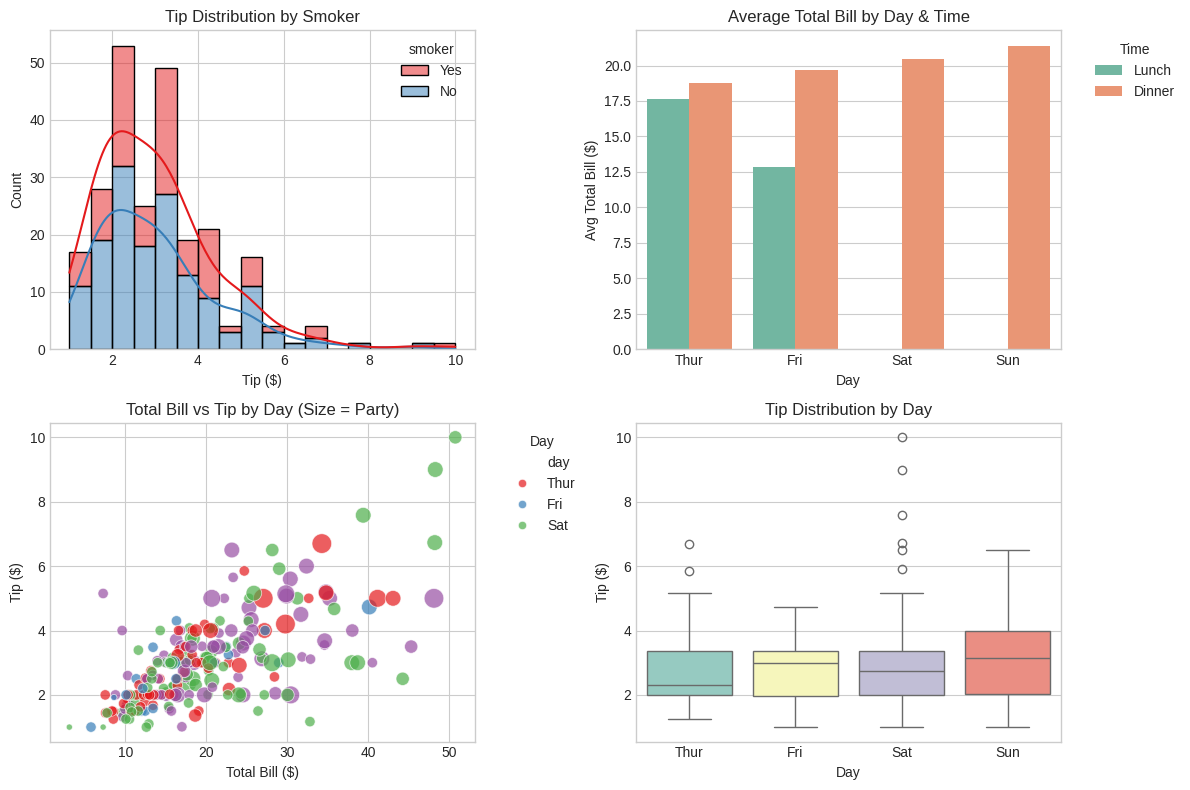


1️⃣ Tip Distribution by Smoker
Fumadores y no fumadores muestran distribuciones similares, con la mayoría de propinas entre $2 y $5.
Fumadores tienden a dejar propinas ligeramente más altas en la cola superior.

2️⃣ Average Total Bill by Day & Time
Sábados y domingos presentan las cuentas promedio más altas; solo hay cenas (probablemente porque refleja el turno de la persona que recolectó los datos).
La hora y el día son factores clave para planificar personal y stock.

3️⃣ Total Bill vs Tip (Size = Party)
Relación positiva: a mayor total_bill, mayor propina.
Mesas grandes tienden a dar propinas más altas.
Los días de fin de semana dominan los montos altos.

4️⃣ Tip Distribution by Day
Jueves tiene propinas más bajas y menor dispersión.
Viernes y fines de semana muestran medianas más altas y mayor rango.
Sabados: outliers de tipos por montos significativamente superiores


In [64]:
# ===========================================
# Tips Dataset
# ===========================================

# import seaborn as sns
# import matplotlib.pyplot as plt

# # Load dataset
# tips = sns.load_dataset("tips")

#(todo esto ya lo tengo de los comandos anteriores)


# Create 2x2 dashboard
fig, axes = plt.subplots(2, 2, figsize=(12,8))

# ---------------------------
# Top-Left: Tip Distribution by Smoker
sns.histplot(data=tips, x="tip", hue="smoker", kde=True, multiple="stack", ax=axes[0,0], palette="Set1")
axes[0,0].set_title("Tip Distribution by Smoker")
axes[0,0].set_xlabel("Tip ($)")
axes[0,0].set_ylabel("Count")

# Top-Right: Average Total Bill by Day & Time
sns.barplot(data=tips, x="day", y="total_bill", hue="time", ci=None, palette="Set2", ax=axes[0,1])
axes[0,1].set_title("Average Total Bill by Day & Time")
axes[0,1].set_xlabel("Day")
axes[0,1].set_ylabel("Avg Total Bill ($)")
# mover la leyenda fuera del gráfico
axes[0,1].legend(title="Time", bbox_to_anchor=(1.05, 1), loc='upper left')

# Bottom-Left: Total Bill vs Tip (Size = Party)
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="day", size="size", sizes=(20,200), palette="Set1", alpha=0.7, ax=axes[1,0])
axes[1,0].set_title("Total Bill vs Tip by Day (Size = Party)")
axes[1,0].set_xlabel("Total Bill ($)")
axes[1,0].set_ylabel("Tip ($)")
# crear leyenda clara para hue (días)
handles, labels = axes[1,0].get_legend_handles_labels()
# separa los días de los tamaños
day_count = len(tips['day'].unique())
axes[1,0].legend(handles=handles[:day_count], labels=labels[:day_count], title="Day", bbox_to_anchor=(1.05, 1), loc='upper left')


# Bottom-Right: Tip Distribution by Day
sns.boxplot(data=tips, x="day", y="tip", palette="Set3", ax=axes[1,1])
axes[1,1].set_title("Tip Distribution by Day")
axes[1,1].set_xlabel("Day")
axes[1,1].set_ylabel("Tip ($)")

plt.tight_layout()
plt.show()

# Interpretación Panel
print('''
1️⃣ Tip Distribution by Smoker
Fumadores y no fumadores muestran distribuciones similares, con la mayoría de propinas entre $2 y $5.
Podria sospecharse que los fumadores tienden a dejar propinas ligeramente más altas en la cola superior.

2️⃣ Average Total Bill by Day & Time
Sábados y domingos presentan las cuentas promedio más altas; solo hay cenas (probablemente porque refleja el turno de la persona que recolectó los datos).
La hora y el día son factores clave para planificar personal y stock.

3️⃣ Total Bill vs Tip (Size = Party)
Relación positiva: a mayor total_bill, mayor propina.
Mesas grandes tienden a dar propinas más altas.
Los días de fin de semana dominan los montos altos.

4️⃣ Tip Distribution by Day
Jueves tiene propinas más bajas y menor dispersión.
Viernes y fines de semana muestran medianas más altas y mayor rango.
Sabados: outliers de tipos por montos significativamente superiores''')


---

# Bonus: Working with Binary/Categorical Variables in Scatter Plots

Sometimes you want to visualize a numeric variable against a Yes/No outcome.

---

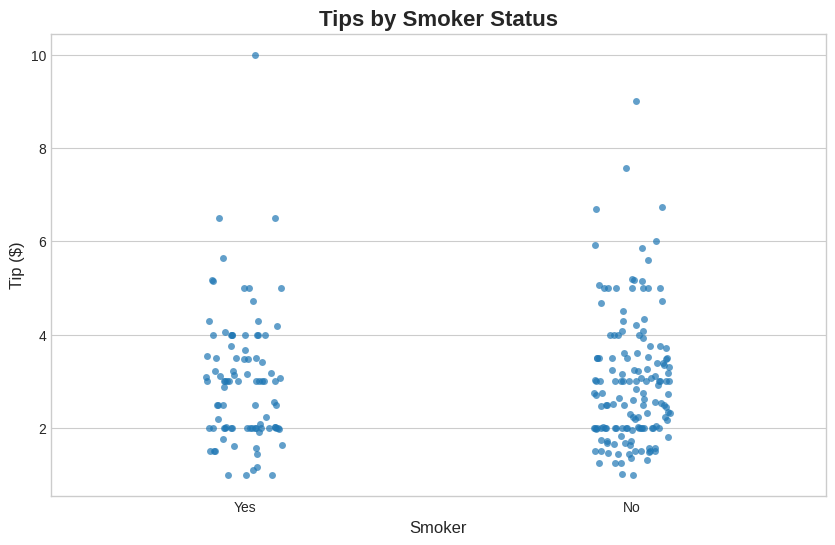

stripplot() shows individual points - good for categorical vs numeric.
Each point is one transaction. Jitter prevents overlap.


In [65]:
# BONUS: Visualizing binary outcomes
# Example: Does smoker status relate to tip amount?

plt.figure(figsize=(10, 6))

# stripplot shows individual points with jitter (prevents overlap)
sns.stripplot(data=tips, x='smoker', y='tip', alpha=0.7, jitter=True)

plt.title('Tips by Smoker Status', fontsize=16, fontweight='bold')
plt.xlabel('Smoker', fontsize=12)
plt.ylabel('Tip ($)', fontsize=12)
plt.show()

print("stripplot() shows individual points - good for categorical vs numeric.")
print("Each point is one transaction. Jitter prevents overlap.")

In [66]:
# If you need to convert Yes/No to 1/0 for other analyses:
tips_copy = tips.copy()
tips_copy['smoker_numeric'] = tips_copy['smoker'].map({'Yes': 1, 'No': 0})

print("Converting categorical to numeric:")
print(tips_copy[['smoker', 'smoker_numeric']].head())
print("\nUse .map({'Yes': 1, 'No': 0}) to convert.")

Converting categorical to numeric:
  smoker smoker_numeric
0     No              0
1     No              0
2     No              0
3     No              0
4     No              0

Use .map({'Yes': 1, 'No': 0}) to convert.
